
1. 하나은행에서 환율 정보 가져오기
2. 1995-01-03- 어제까지(2025-04-08)
3. 월-금 datetime clode에 물어봐서 해결 (날짜_월-금 조건물어보자)
*weekday 물어보기
4. selenium으로 날짜입력 후 환율 조회
5. pd.read_html
6. mysql에 exchange_rate 데이터베이스 exchange_rate 테이블로 저장

# 하나은행에서 환율조회 부분 찾아서 selenium으로 열기
* 날짜 입력부분 찾아 날짜 넣기
* 조회 버튼 찾아 버튼 클릭하기
* 조회된 데이터를 pd.read_html을 이용해 dataframe으로 만들기
* 데이터 프레임에 조회 날짜 컬럼 만들어서 날짜 추가하기

### 조회와 환율 테이블만 있는 페이지로 이동

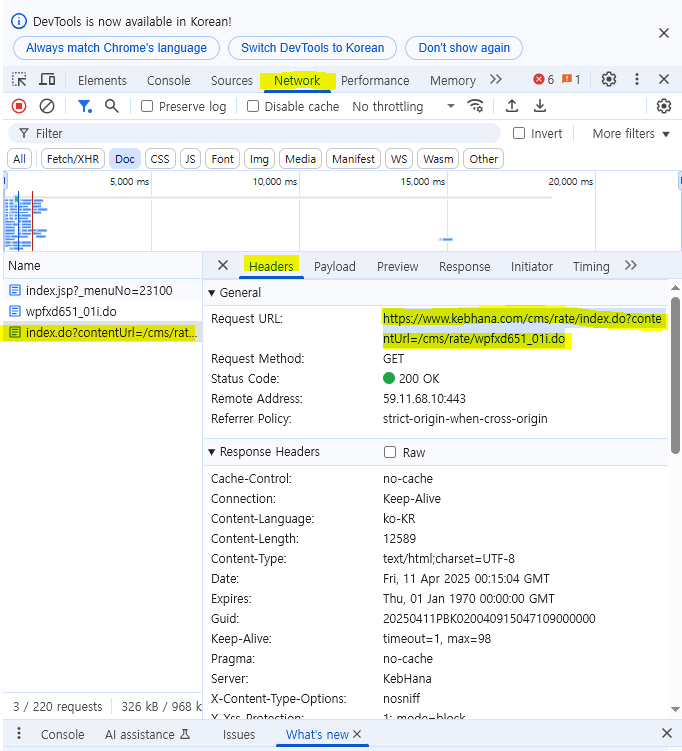

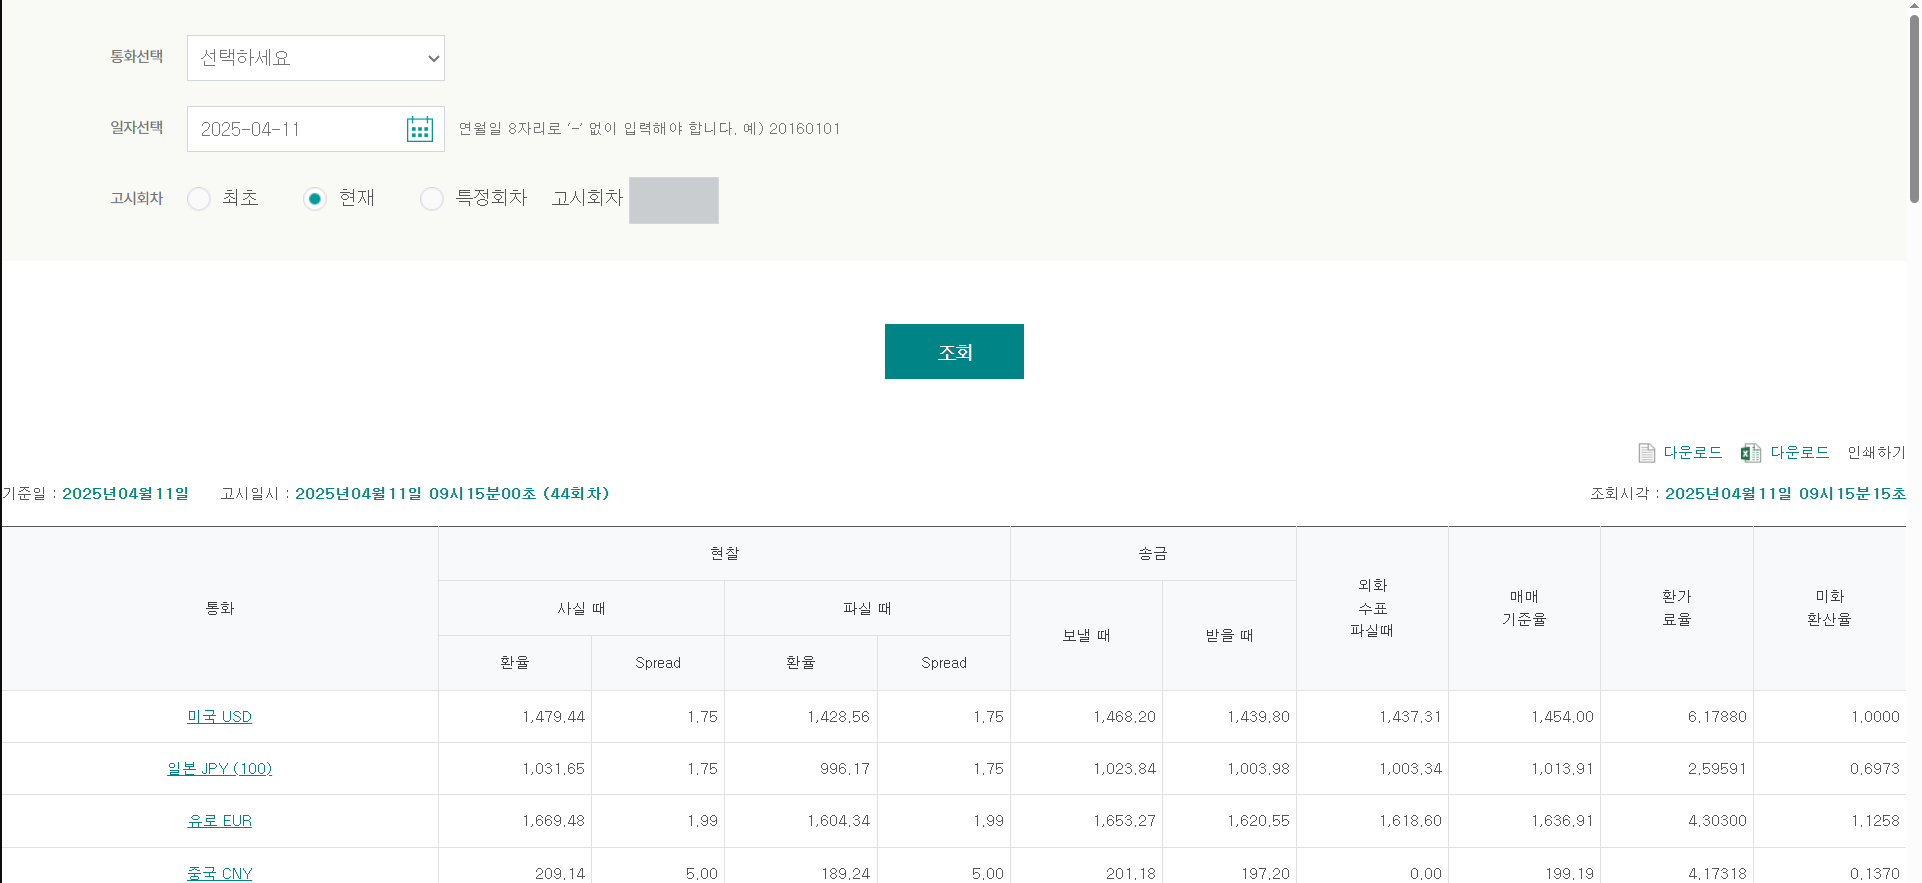

In [1]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
import pandas as pd

options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")


driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )

url = "https://www.kebhana.com/cms/rate/index.do?contentUrl=/cms/rate/wpfxd651_01i.do"
driver.get(url)

In [2]:
input_box = driver.find_element(By.CSS_SELECTOR, "#tmpInqStrDt")
input_box.clear()
input_box.send_keys("20250408")
search_button = driver.find_element(By.CSS_SELECTOR, "#HANA_CONTENTS_DIV > div.btnBoxCenter > a")
search_button.click()

In [3]:
driver.find_element(By.CSS_SELECTOR, "#tmpInqStrDt").get_attribute("outerHTML")

'<input type="text" id="tmpInqStrDt" name="tmpInqStrDt" maxlength="10" placeholder="2016-01-26" title="조회일 입력" value="2025-04-16" onchange="pbk.foreign.rate.pbld.prs.chkInqStrDt(document.forms[\'inqFrm\']);" isinit="true">'

In [4]:
# 날짜 입력
#tmpInqStrDt
date_input = driver.find_element(By.CSS_SELECTOR, "#tmpInqStrDt")
date_input.clear()
date_input.send_keys("20250408")
date_input.send_keys(Keys.ENTER)

# 조회버튼 클릭
#HANA_CONTENTS_DIV > div.btnBoxCenter > a
search_button = driver.find_element(By.CSS_SELECTOR, "#HANA_CONTENTS_DIV > div.btnBoxCenter > a")
search_button.click()

In [5]:
from io import StringIO

In [ ]:
# 환율 테이블 정보
#tblBasic leftNone

df = pd.read_html(StringIO(driver.find_element(By.CSS_SELECTOR, ".tblBasic.leftNone").get_attribute('outerHTML')))[0]
df

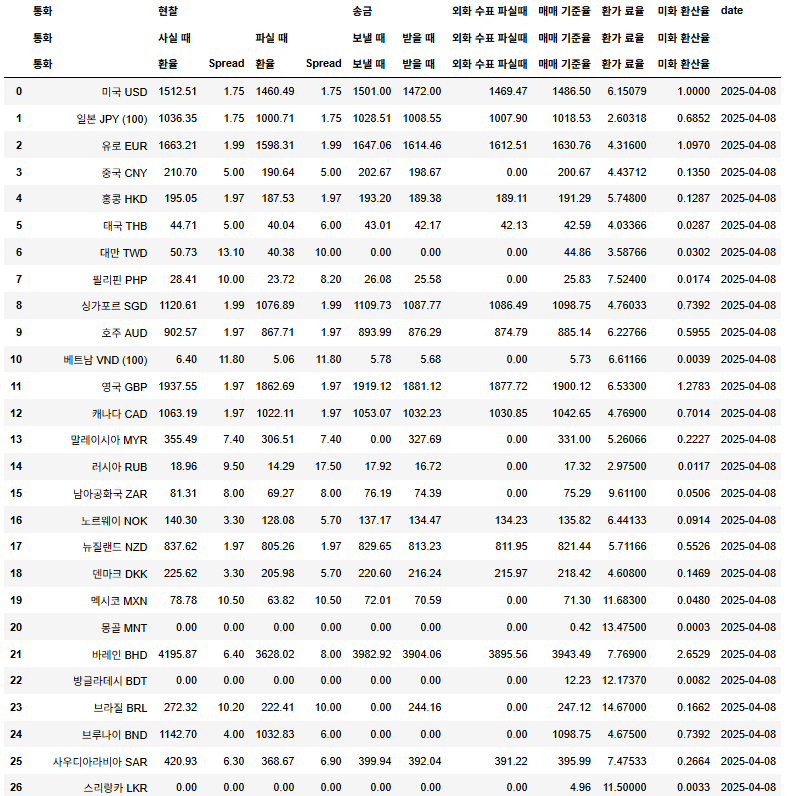

In [ ]:
# date 리스트 - 인덱스로 지정하면 자동으로 채워진다
df['date'] = "2025-04-08"
df

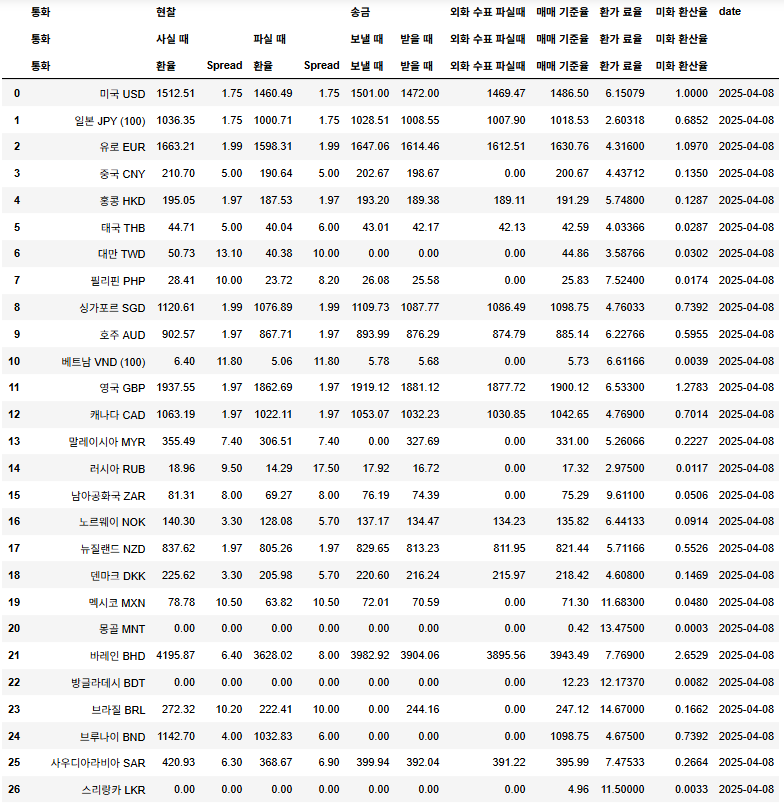

# 날짜 생성하기
* 1995-01-03- 어제까지(2025-04-08) 날짜 생성하기
* 평일만 날짜 생성
* 날짜 리스트에 모든 날짜 저장

In [24]:
from datetime import datetime

In [26]:
import datetime

In [25]:
# weekday() : 요일 표시
datetime.now().weekday()

2

In [27]:
print(datetime.datetime.now(), type(datetime.datetime.now()))

2025-04-16 21:54:26.558515 <class 'datetime.datetime'>


In [28]:
start_day = datetime.date(2025, 4, 1)
end_day = datetime.date(2025, 4, 11)

In [29]:
current_date = datetime.date(2025, 4, 1)

In [41]:
# weekday() 는 월 0, 화 1, 수 2, 목 3, 금 4, 토 5, 일 6
for days in range(1, 10):
#     print(current_date + datetime.timedelta(days=days))
    day = current_date + datetime.timedelta(days=days)
    if day.weekday() < 5:
        print(day, day.weekday())

2025-04-02 2
2025-04-03 3
2025-04-04 4
2025-04-07 0
2025-04-08 1
2025-04-09 2
2025-04-10 3


In [33]:
# 날짜 데이터 타입은 논리 연산(비교 가능)
start_day != end_day

True

In [ ]:
# datetime.timedelta() 로 날짜 증감 가능

In [34]:
day_increased = start_day + datetime.timedelta(days=9)
print(f"start_day: {start_day}\n, day_increased: {day_increased}\n, end_day: {end_day}\n", day_increased==end_day)

start_day: 2025-04-01
, day_increased: 2025-04-10
, end_day: 2025-04-11
 False


# 시작일과 끝일을 입력해서 평일만 생성하기

In [50]:
start_date = datetime.date(2025, 4, 1)
end_date = datetime.date(2025, 4, 8)

In [51]:
date_list = []
while start_date <= end_date:
    # 평일인지 필터링
    if start_date.weekday() < 5:
        date_list.append(start_date)
    start_date += datetime.timedelta(days = 1)
date_list

[datetime.date(2025, 4, 1),
 datetime.date(2025, 4, 2),
 datetime.date(2025, 4, 3),
 datetime.date(2025, 4, 4),
 datetime.date(2025, 4, 7),
 datetime.date(2025, 4, 8)]

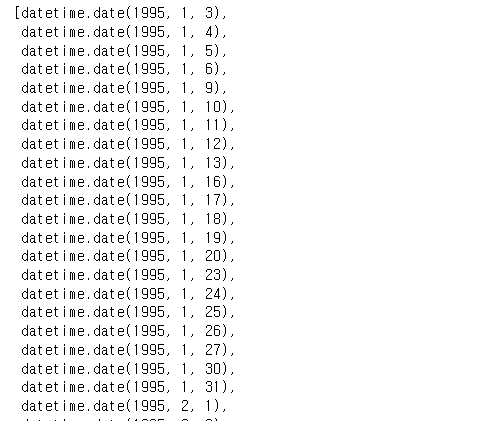

In [52]:
str(date_list[0]).replace("-", "")

'20250401'

In [54]:
day_increases = start_day + datetime.timedelta(days=10)
print(start_day, day_increases, end_day, day_increases==end_day)

2025-04-01 2025-04-11 2025-04-08 False


## 컬럼명 변경하기

In [ ]:
# list -> 1개의 문자열로 합치는 함수: join()
# 문자열을 -> list : split()

In [ ]:
# 중복된 자료 제거 1 set 집합자료형
# set 자료형은 순서가 없음
print(set(df.columns[0]))
print(set(df.columns[1]))
print(set(df.columns[1]))


In [55]:
df.columns

MultiIndex([(       '통화',        '통화',        '통화'),
            (       '현찰',      '사실 때',        '환율'),
            (       '현찰',      '사실 때',    'Spread'),
            (       '현찰',      '파실 때',        '환율'),
            (       '현찰',      '파실 때',    'Spread'),
            (       '송금',      '보낼 때',      '보낼 때'),
            (       '송금',      '받을 때',      '받을 때'),
            ('외화 수표 파실때', '외화 수표 파실때', '외화 수표 파실때'),
            (   '매매 기준율',    '매매 기준율',    '매매 기준율'),
            (    '환가 료율',     '환가 료율',     '환가 료율'),
            (   '미화 환산율',    '미화 환산율',    '미화 환산율'),
            (     'date',          '',          '')],
           )

In [56]:
new_cols = []
for col in df.columns:
    print(col)
    if col[0] == col[1] == col[2]:
        new_cols.append(col[0].strip().replace(" ", "_"))
#         print(col[0].strip().replace(" ", "_"), end="\n\n")
    else:
        new_cols.append(" ".join(col).strip().replace(" ", "_"))

('통화', '통화', '통화')
('현찰', '사실 때', '환율')
('현찰', '사실 때', 'Spread')
('현찰', '파실 때', '환율')
('현찰', '파실 때', 'Spread')
('송금', '보낼 때', '보낼 때')
('송금', '받을 때', '받을 때')
('외화 수표 파실때', '외화 수표 파실때', '외화 수표 파실때')
('매매 기준율', '매매 기준율', '매매 기준율')
('환가 료율', '환가 료율', '환가 료율')
('미화 환산율', '미화 환산율', '미화 환산율')
('date', '', '')


In [57]:
new_cols

['통화',
 '현찰_사실_때_환율',
 '현찰_사실_때_Spread',
 '현찰_파실_때_환율',
 '현찰_파실_때_Spread',
 '송금_보낼_때_보낼_때',
 '송금_받을_때_받을_때',
 '외화_수표_파실때',
 '매매_기준율',
 '환가_료율',
 '미화_환산율',
 'date']

In [ ]:
df.columns = new_cols
df

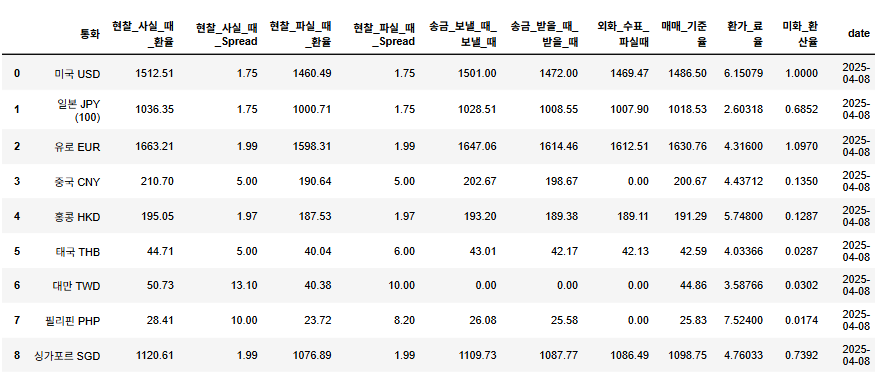

In [59]:
df.columns

Index(['통화', '현찰_사실_때_환율', '현찰_사실_때_Spread', '현찰_파실_때_환율', '현찰_파실_때_Spread',
       '송금_보낼_때_보낼_때', '송금_받을_때_받을_때', '외화_수표_파실때', '매매_기준율', '환가_료율',
       '미화_환산율', 'date'],
      dtype='object')

In [ ]:
# 컬럼의 일부만 조회하고 싶을 때, 조회 순서를 바꾸고 싶을 때
# dt[['컬럼명1'...'컬럼명-1']]

In [61]:
df = df[['date', '통화', '현찰_사실_때_환율', '현찰_사실_때_Spread', '현찰_파실_때_환율', '현찰_파실_때_Spread',
       '송금_보낼_때_보낼_때', '송금_받을_때_받을_때', '외화_수표_파실때', '매매_기준율', '환가_료율',
       '미화_환산율', ]]
df

,date,통화,현찰_사실_때_환율,현찰_사실_때_Spread,현찰_파실_때_환율,현찰_파실_때_Spread,송금_보낼_때_보낼_때,송금_받을_때_받을_때,외화_수표_파실때,매매_기준율,환가_료율,미화_환산율
0,2025-04-08,미국 USD,1512.51,1.75,1460.49,1.75,1501.00,1472.00,1469.47,1486.50,6.15079,1.0000
1,2025-04-08,일본 JPY (100),1036.35,1.75,1000.71,1.75,1028.51,1008.55,1007.90,1018.53,2.60318,0.6852
2,2025-04-08,유로 EUR,1663.21,1.99,1598.31,1.99,1647.06,1614.46,1612.51,1630.76,4.31600,1.0970
3,2025-04-08,중국 CNY,210.70,5.00,190.64,5.00,202.67,198.67,0.00,200.67,4.43712,0.1350
4,2025-04-08,홍콩 HKD,195.05,1.97,187.53,1.97,193.20,189.38,189.11,191.29,5.74800,0.1287
5,2025-04-08,태국 THB,44.71,5.00,40.04,6.00,43.01,42.17,42.13,42.59,4.03366,0.0287
6,2025-04-08,대만 TWD,50.73,13.10,40.38,10.00,0.00,0.00,0.00,44.86,3.58766,0.0302
7,2025-04-08,필리핀 PHP,28.41,10.00,23.72,8.20,26.08,25.58,0.00,25.83,7.52400,0.0174
8,2025-04-08,싱가포르 SGD,1120.61,1.99,1076.89,1.99,1109.73,1087.77,1086.49,1098.75,4.76033,0.7392
9,2025-04-08,호주 AUD,902.57,1.97,867.71,1.97,893.99,876.29,874.79,885.14,6.22766,0.5955


# 코드 합쳐서 전체 날짜 데이터 추출하기

In [62]:
import datetime
today = datetime.datetime.now()
print(today.year)
print(today.month)
print(today.day)

2025
4
16


In [26]:
# 컬럼 이름 변경하기
def new_col(df):
    new_cols = []
    for col in df.columns:
        if col[0] == col[1] == col[2]:
            new_cols.append(col[0].strip().replace(" ", "_"))
        else:
            new_cols.append(" ".join(col).strip().replace(" ", "_"))
    return new_cols

In [29]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import pandas as pd
import datetime
from io import StringIO
import time
from ex_dbio import to_ex_db

options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")
# 웹브라우저가 백그라운드에서 작동하도록 설정
options.add_argument("--headless")
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )

url = "https://www.kebhana.com/cms/rate/index.do?contentUrl=/cms/rate/wpfxd651_01i.do"
driver.get(url)

wait = WebDriverWait(driver, 10)


# 시작일과 끝일 입력해서 날짜 리스트 생성
start_date = datetime.date(1995, 1, 3)
end_date = datetime.date(2025, 4, 10)

date_list = []
while start_date <= end_date:
    # 평일인지 필터링
    if start_date.weekday() < 5:
        date_list.append(start_date)
    start_date += datetime.timedelta(days = 1)

for date in date_list:
    
    # 날짜 입력
    # #tmpInqStrDt
    date_input = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "#tmpInqStrDt")))
    date_input.clear()
    date_input.send_keys(str(date).replace("-", ""))
    date_input.send_keys(Keys.ENTER)
    

    # 조회버튼 클릭
    # #HANA_CONTENTS_DIV > div.btnBoxCenter > a
    search_button = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "#HANA_CONTENTS_DIV > div.btnBoxCenter > a")))
    search_button.click()
    time.sleep(2)
    df = pd.read_html(StringIO(driver.find_element(By.CSS_SELECTOR, ".tblBasic.leftNone").get_attribute("outerHTML")))[0]
    df['date'] = date
    new_columns = new_col(df)
    df.columns = new_columns
    df = df[['date', '통화', '현찰_사실_때_환율', '현찰_사실_때_Spread', '현찰_파실_때_환율', '현찰_파실_때_Spread',
       '송금_보낼_때_보낼_때', '송금_받을_때_받을_때', '외화_수표_파실때', '매매_기준율', '환가_료율',
       '미화_환산율']]
    to_ex_db(df)
    # 백그라운드에서 잘 돌아가고 있는지 확인할 수 있도록 남겨두자!
    print(f"{date} 환율정보 DB 저장 완료", end="\r")

# exe 실행파일로 저장하기

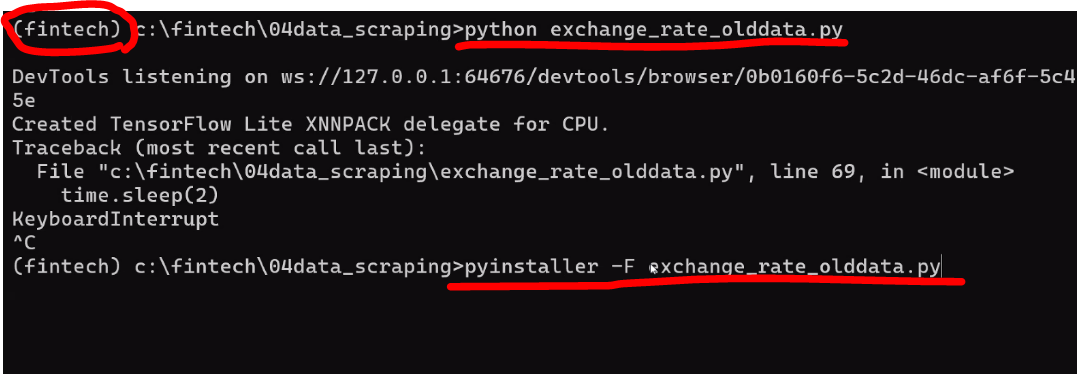

# 오늘의 환율 데이터 저장하기

In [1]:
# 컬럼 이름 변경하기
def new_col(df):
    new_cols = []
    for col in df.columns:
        if col[0] == col[1] == col[2]:
            new_cols.append(col[0].strip().replace(" ", "_"))
        else:
            new_cols.append(" ".join(col).strip().replace(" ", "_"))
    return new_cols

In [3]:
# import datetime
# today = datetime.datetime.now()
# date = f"{today.year}-{today.month:02d}-{today.day:02d}"
# print(date)

2025-04-11


In [3]:
from selenium import webdriver
from selenium.webdriver.chrome.service import Service
from selenium.webdriver.chrome.options import Options
from webdriver_manager.chrome import ChromeDriverManager
from selenium.webdriver.common.by import By
from selenium.webdriver.common.keys import Keys
from selenium.webdriver.support.ui import WebDriverWait
from selenium.webdriver.support import expected_conditions as EC
import pandas as pd
import datetime
from io import StringIO
import time
from ex_dbio import to_ex_db_test

options = Options()
options.add_experimental_option("detach", True)
options.add_argument("start-maximized")
options.add_argument("Chrome/135.0.0.0")
options.add_argument("lang=ko_KR")
# 웹브라우저가 백그라운드에서 작동하도록 설정
options.add_argument("--headless")
options.add_argument("--no-sandbox")
options.add_argument("--disable-dev-shm-usage")

driver = webdriver.Chrome(
    service=Service(ChromeDriverManager().install()),
    options=options
    )

url = "https://www.kebhana.com/cms/rate/index.do?contentUrl=/cms/rate/wpfxd651_01i.do"
driver.get(url)

wait = WebDriverWait(driver, 20)


# 오늘날짜 20250411 형식으로 가져오기
today = datetime.datetime.now()
date = f"{today.year}-{today.month:02d}-{today.day:02d}"


# 날짜 입력
# #tmpInqStrDt
date_input = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "#tmpInqStrDt")))
date_input.clear()
date_input.send_keys(date.replace("-", ""))
date_input.send_keys(Keys.ENTER)
    

# 조회버튼 클릭
# #HANA_CONTENTS_DIV > div.btnBoxCenter > a
search_button = wait.until(EC.presence_of_element_located((By.CSS_SELECTOR, "#HANA_CONTENTS_DIV > div.btnBoxCenter > a")))
search_button.click()
time.sleep(2)

df = pd.read_html(StringIO(driver.find_element(By.CSS_SELECTOR, ".tblBasic.leftNone").get_attribute('outerHTML')))[0]
df['date'] = date
new_columns = new_col(df)
df.columns = new_columns
df = df[['date', '통화', '현찰_사실_때_환율', '현찰_사실_때_Spread', '현찰_파실_때_환율', '현찰_파실_때_Spread',
   '송금_보낼_때_보낼_때', '송금_받을_때_받을_때', '외화_수표_파실때', '매매_기준율', '환가_료율',
   '미화_환산율']]
to_ex_db_test(df)
# 백그라운드에서 잘 돌아가고 있는지 확인할 수 있도록 남겨두자!
print(f"{date} 환율정보 DB 저장 완료", end="\r")